In [77]:
import os
import json
import math
import random
import zipfile
import warnings

def explore(path, depth=0):
    try:
        for item in os.listdir(path):
            full = os.path.join(path, item)
            print('  ' * depth + '└── ' + item)
            if os.path.isdir(full) and depth < 4:
                explore(full, depth + 1)
    except:
        pass
explore('/kaggle/input/flood-segmentation-nexus-final')

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import cv2
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.utils.data import (
    Dataset,
    DataLoader,
    BatchSampler,
    ConcatDataset
)
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Models
from transformers import (
    Mask2FormerForUniversalSegmentation,
    SegformerForSemanticSegmentation
)

from tqdm.auto import tqdm

try:
    import wandb
    WANDB_AVAILABLE = True
    print("WANDB is available.")
except ImportError:
    WANDB_AVAILABLE = False
    print("WANDB is not available.")

print("All libraries successfully imported!")

WANDB is available.
All libraries successfully imported!


In [78]:
import sys

IN_COLAB  = False
IN_KAGGLE = os.path.exists('/kaggle')

print(f"Kaggle: {IN_KAGGLE}")

gpu_name = os.popen(
    'nvidia-smi --query-gpu=name --format=csv,noheader'
).read().strip()

print(f'GPU : {gpu_name}')

KAGGLE_DATASET_PATH = None
KAGGLE_CKPT_INPUT   = None

print("\nScanning /kaggle/input/ ...")
print("Top-level:", os.listdir('/kaggle/input'))

def find_kaggle_path(keyword, search_root='/kaggle/input'):
    keyword_norm = keyword.lower().replace('-', '').replace('_', '')

    for root, dirs, _ in os.walk(search_root):
        for d in dirs:
            if d.lower().replace('-', '').replace('_', '') == keyword_norm:
                return os.path.join(root, d)

    return None

KAGGLE_DATASET_PATH = find_kaggle_path('floodsegmentationnexusfinal')
KAGGLE_CKPT_INPUT   = find_kaggle_path('checkpointsmask2former')

if KAGGLE_DATASET_PATH:
    print(f'[OK] Dataset found : {KAGGLE_DATASET_PATH}')
    print(f'Contents: {os.listdir(KAGGLE_DATASET_PATH)}')
else:
    print('flood-segmentation-nexus dataset not found')

if KAGGLE_CKPT_INPUT:
    print(f'Checkpoints found: {KAGGLE_CKPT_INPUT}')
    print(f'Files: {os.listdir(KAGGLE_CKPT_INPUT)}')
else:
    KAGGLE_CKPT_INPUT = ''
    print('No checkpoint dataset found')

Kaggle: True
GPU : Tesla T4
Tesla T4

Scanning /kaggle/input/ ...
Top-level: ['datasets']
[OK] Dataset found : /kaggle/input/datasets/viericoventora/flood-segmentation-nexus-final
Contents: ['dataset_640x480', 'sample_submission (1).csv']
No checkpoint dataset found


In [79]:
import random

EXTRACT_PATH = '/kaggle/working'

DATASET_IN_INPUT = (
    os.path.join(KAGGLE_DATASET_PATH, 'flood-segmentation-nexus')
    if KAGGLE_DATASET_PATH else None
)

DATASET_IN_WORKING = os.path.join(
    EXTRACT_PATH,
    'Dataset_Nexus_DolananDataFinal'
)

if DATASET_IN_INPUT and os.path.exists(DATASET_IN_INPUT):
    print(f"[OK] Dataset found in input: {DATASET_IN_INPUT}")

elif os.path.exists(DATASET_IN_WORKING):
    print(f"[OK] Dataset found in working: {DATASET_IN_WORKING}")

elif KAGGLE_DATASET_PATH and os.path.exists(KAGGLE_DATASET_PATH):
    inner = os.listdir(KAGGLE_DATASET_PATH)

    print(f"[INFO] Dataset contents: {inner}")

    ZIP_PATH = os.path.join(
        KAGGLE_DATASET_PATH,
        'flood-segmentation-nexus-final.zip'
    )

    if os.path.exists(ZIP_PATH):
        os.makedirs(EXTRACT_PATH, exist_ok=True)

        print("Extracting dataset...")

        with zipfile.ZipFile(ZIP_PATH, 'r') as z:
            z.extractall(EXTRACT_PATH)

        print("Extraction complete")

    else:
        print(f"Zip file not found. Contents: {inner}")

else:
    raise FileNotFoundError(
        "flood-segmentation-nexus dataset not found"
    )

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(42)

[INFO] Dataset contents: ['dataset_640x480', 'sample_submission (1).csv']
Zip file not found. Contents: ['dataset_640x480', 'sample_submission (1).csv']


In [80]:
BASE_PATH = "/kaggle/input/datasets/viericoventora/flood-segmentation-nexus-final/dataset_640x480/dataset_640x480"

TRAIN_IMG  = os.path.join(BASE_PATH, "train", "img")
TRAIN_MASK = os.path.join(BASE_PATH, "train", "masks")

VAL_IMG    = os.path.join(BASE_PATH, "validation", "img")
VAL_MASK   = os.path.join(BASE_PATH, "validation", "masks")

TEST_IMG   = os.path.join(BASE_PATH, "test", "img")

if os.path.exists(TRAIN_IMG):
    print(f"TRAIN_IMG: {TRAIN_IMG}")
    print(f"TRAIN_MASK: {TRAIN_MASK}")
else:
    print("Wrong.")

TRAIN_IMG: /kaggle/input/datasets/viericoventora/flood-segmentation-nexus-final/dataset_640x480/dataset_640x480/train/img
TRAIN_MASK: /kaggle/input/datasets/viericoventora/flood-segmentation-nexus-final/dataset_640x480/dataset_640x480/train/masks


In [81]:
CLASS_NAMES = {
    0: "background",
    1: "building flooded",
    2: "building non-flooded",
    3: "grass",
    4: "pool",
    5: "road flooded",
    6: "road non-flooded",
    7: "tree",
    8: "vehicle",
    9: "water"
}

NUM_CLASSES  = 10
EMPTY_CLASSES = {}
RARE_CLASSES  = {1, 4, 7, 8}

CLASS_WEIGHTS = torch.tensor(
    [[1.5, 2.0, 0.8, 0.8, 2.5, 0.6, 0.5, 8.0, 8.0, 2.0]],
    dtype=torch.float32
)

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

MODEL_NAME = "facebook/mask2former-swin-tiny-ade-semantic"

TRAIN_CONFIG = {
    'num_epochs': 50,
    'lr_backbone': 1e-5,
    'lr_head': 1e-4,
    'weight_decay': 0.05,
    'grad_clip': 1.0,
    'save_dir': '/kaggle/working/checkpoints_mask2former-swin-tiny-ade-semantic',
    'early_stop_patience': 10,
    'accumulation_steps': 4,
    'lovasz_warmup_epochs'  : 3,
    'lovasz_weight': 0.75,
    'rare_ratio': 0.50,
    'water_ratio': 0.10,
    'batch_size': 2,
    'poly_power': 0.9,
    'warmup_steps': 125,
}

os.makedirs(TRAIN_CONFIG['save_dir'], exist_ok=True)

if 'KAGGLE_CKPT_INPUT' not in dir() or KAGGLE_CKPT_INPUT is None:
    KAGGLE_CKPT_INPUT = ''

def resolve_ckpt(filename):
    input_path = os.path.join(
        KAGGLE_CKPT_INPUT,
        filename
    )

    working_path = os.path.join(
        TRAIN_CONFIG['save_dir'],
        filename
    )

    if os.path.exists(input_path):
        return input_path

    return working_path

CKPT_M2F = resolve_ckpt('best_mask2former.pth')

print(f"SAVE_DIR : {TRAIN_CONFIG['save_dir']}")
print(f"CKPT_M2F : {CKPT_M2F}")
print(f"Model    : {MODEL_NAME}")
print("Config ready")

SAVE_DIR : /kaggle/working/checkpoints_mask2former-swin-tiny-ade-semantic
CKPT_M2F : /kaggle/working/checkpoints_mask2former-swin-tiny-ade-semantic/best_mask2former.pth
Model    : facebook/mask2former-swin-tiny-ade-semantic
Config ready


In [82]:
import json, base64, io, os, random
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
from collections import Counter
from tqdm.auto import tqdm

IMG_SIZE = (640, 480)

def decode_bitmap(bitmap_data, origin):
    try:
        img  = Image.open(io.BytesIO(base64.b64decode(bitmap_data)))
        mask = np.array(img)
        if mask.ndim == 3:
            mask = mask[:, :, 3] if mask.shape[2] == 4 else mask[:, :, 0]
        return mask, origin
    except Exception:
        return None, None

def json_to_mask(json_path, image_size=IMG_SIZE):
    with open(json_path) as f:
        ann = json.load(f)
    w, h     = image_size
    mask     = np.zeros((h, w), dtype=np.uint8)
    name2id  = {v: k for k, v in CLASS_NAMES.items()}
    for obj in ann.get('objects', []):
        cname = obj.get('classTitle', '')
        if cname not in name2id:
            continue
        cid    = name2id[cname]
        bdata  = obj.get('bitmap', {}).get('data', '')
        origin = obj.get('bitmap', {}).get('origin', [0, 0])
        if not bdata:
            continue
        om, origin = decode_bitmap(bdata, origin)
        if om is None:
            continue
        x, y   = origin
        oh, ow = om.shape
        xe, ye = min(x + ow, w), min(y + oh, h)
        region = mask[y:ye, x:xe]
        region[om[:ye-y, :xe-x] > 0] = cid
        mask[y:ye, x:xe] = region
    return mask

In [83]:
train_ids = sorted([os.path.splitext(f)[0] for f in os.listdir(TRAIN_IMG) if f.endswith('.jpg')])
val_ids_all = sorted([os.path.splitext(f)[0] for f in os.listdir(VAL_IMG) if f.endswith('.jpg')])

def compute_distribution(mask_dir, id_list):
    total_counts = Counter()
    per_image    = []
    for fname in tqdm(id_list, desc="Analyzing"):
        img_id    = os.path.splitext(fname)[0] if fname.endswith('.jpg') else fname
        mask_path = os.path.join(mask_dir, f"{img_id}.png")
        if not os.path.exists(mask_path):
            continue
        mask            = np.array(Image.open(mask_path))
        unique, counts  = np.unique(mask, return_counts=True)
        total           = mask.size
        row             = {'image_id': img_id}
        for cls, cnt in zip(unique, counts):
            name               = CLASS_NAMES[cls]
            total_counts[name] += cnt
            row[name]           = (cnt / total) * 100
        per_image.append(row)
    return total_counts, pd.DataFrame(per_image).set_index('image_id')

train_counts, train_dist_df = compute_distribution(TRAIN_MASK, train_ids)
val_counts,   val_dist_df   = compute_distribution(VAL_MASK,   val_ids_all)
total_train_px = 640 * 480 * len(train_dist_df)
total_val_px   = 640 * 480 * len(val_dist_df)

print(f"\n{'Class':<25} {'Train px':>12} {'Train %':>9} {'Val %':>9}")
print("-" * 70)
for cid in range(NUM_CLASSES):
    name   = CLASS_NAMES[cid]
    tr_px  = train_counts.get(name, 0)
    tr_pct = (tr_px / total_train_px) * 100
    vl_pct = (val_counts.get(name, 0) / total_val_px) * 100
    print(f"{name:<25} {tr_px:>12,} {tr_pct:>8.2f}% {vl_pct:>8.2f}%")

non_bg    = {k: v for k, v in train_counts.items() if k != "background"}
max_cls   = max(non_bg, key=non_bg.get)
min_cls   = min(non_bg, key=non_bg.get)
imbalance = non_bg[max_cls] / non_bg[min_cls]
print(f"\nMost frequent  : {max_cls}")
print(f"Least frequent : {min_cls}")
print(f"Imbalance ratio: {imbalance:.1f}:1")


Analyzing:   0%|          | 0/1445 [00:00<?, ?it/s]

Analyzing:   0%|          | 0/450 [00:00<?, ?it/s]


Class                         Train px   Train %     Val %
----------------------------------------------------------------------
background                   7,644,786     1.72%     2.27%
building flooded             6,940,896     1.56%     1.74%
building non-flooded        14,446,329     3.25%     2.88%
grass                       12,199,829     2.75%     2.48%
pool                        24,491,705     5.52%     5.89%
road flooded                48,574,411    10.94%    11.07%
road non-flooded            77,509,681    17.46%    18.66%
tree                           788,328     0.18%     0.17%
vehicle                        905,084     0.20%     0.19%
water                      250,402,951    56.41%    54.66%

Most frequent  : water
Least frequent : tree
Imbalance ratio: 317.6:1



8966 classes: [4 5 6 7 9]


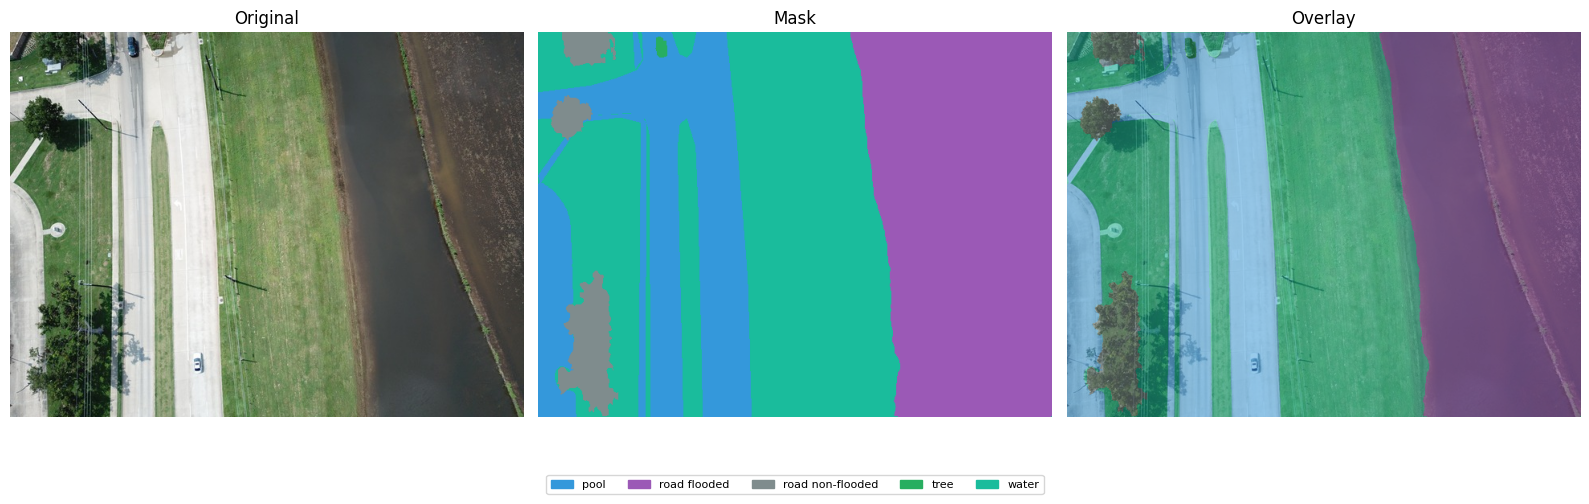


6676 classes: [6 9]


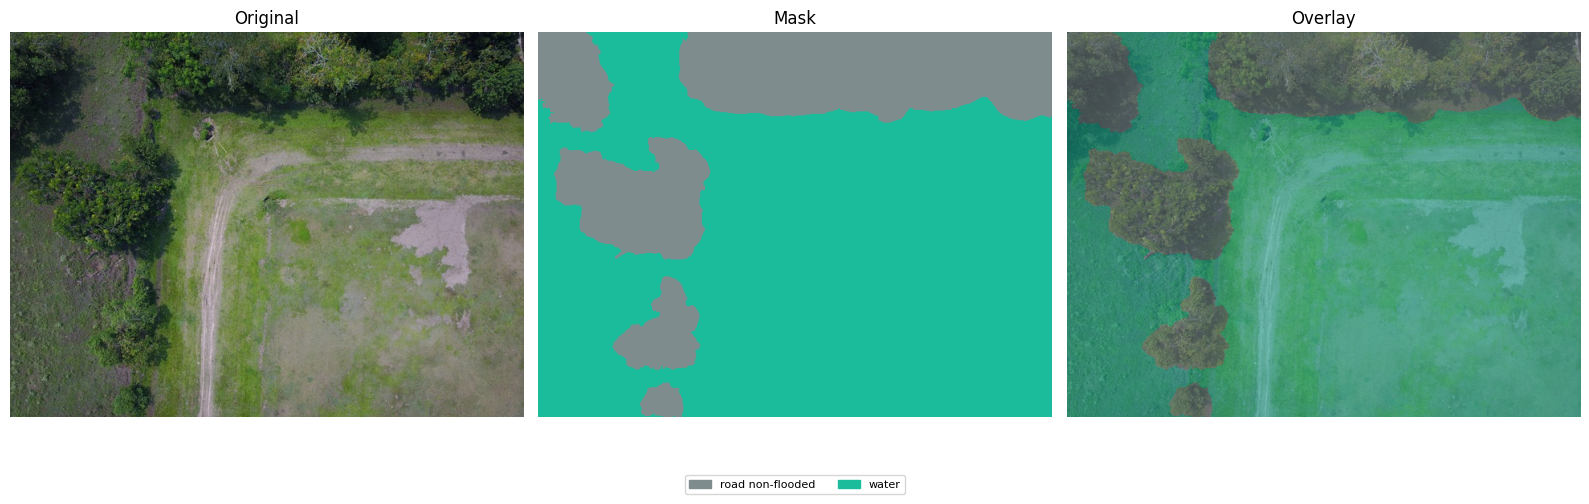


6358 classes: [4 5 6 9]


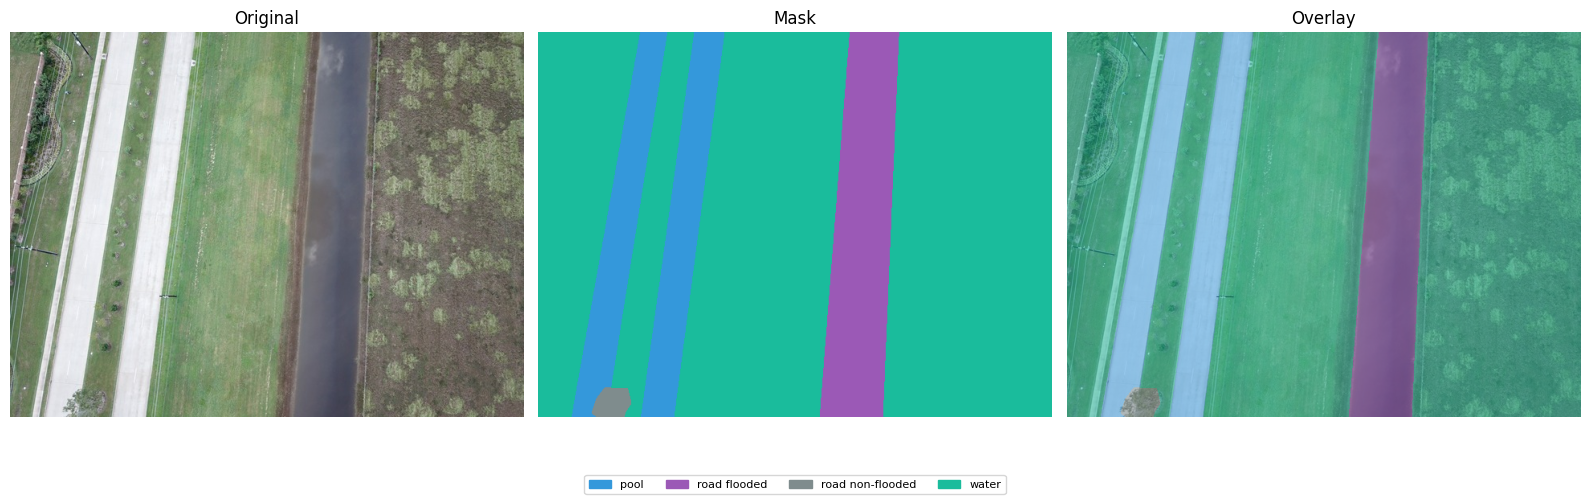

In [84]:
CLASS_COLORS = {
    0: "#000000", 1: "#e74c3c", 2: "#34495e", 3: "#2ecc71", 4: "#3498db",
    5: "#9b59b6", 6: "#7f8c8d", 7: "#27ae60", 8: "#f1c40f", 9: "#1abc9c"
}

def visualize_sample(img_path, mask, figsize=(16, 5)):
    img     = np.array(Image.open(img_path).convert('RGB'))
    colored = np.zeros((*mask.shape, 3), dtype=np.uint8)
    for cid, hex_c in CLASS_COLORS.items():
        rgb                  = tuple(int(hex_c.lstrip('#')[i:i+2], 16) for i in (0, 2, 4))
        colored[mask == cid] = rgb
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    axes[0].imshow(img);     axes[0].set_title('Original');  axes[0].axis('off')
    axes[1].imshow(colored); axes[1].set_title('Mask');      axes[1].axis('off')
    axes[2].imshow(img);     axes[2].imshow(colored, alpha=0.5)
    axes[2].set_title('Overlay'); axes[2].axis('off')
    patches = [mpatches.Patch(color=CLASS_COLORS[i], label=CLASS_NAMES[i])
               for i in range(NUM_CLASSES) if np.any(mask == i)]
    fig.legend(handles=patches, loc='lower center', ncol=5, fontsize=8, bbox_to_anchor=(0.5, -0.05))
    plt.tight_layout(); plt.show()

for fname in random.sample(train_ids, 3):
    img_id = fname if not fname.endswith('.jpg') else os.path.splitext(fname)[0]
    mask   = np.array(Image.open(os.path.join(TRAIN_MASK, f"{img_id}.png")))
    print(f"\n{img_id} classes: {np.unique(mask)}")
    visualize_sample(os.path.join(TRAIN_IMG, f"{img_id}.jpg"), mask)

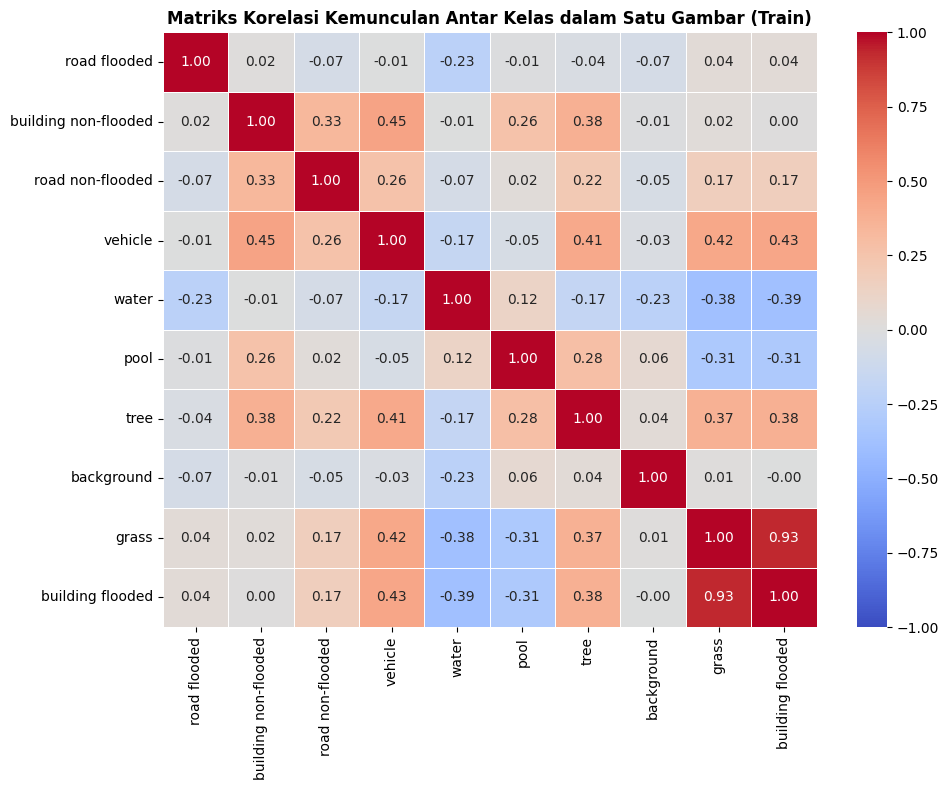

In [85]:
binary_df = (train_dist_df > 0).astype(int)
corr_matrix = binary_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriks Korelasi Kemunculan Antar Kelas dalam Satu Gambar (Train)', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

In [86]:
anomaly_counter = 0
for fname in tqdm(train_ids, desc="Scanning Anomalies"):
    mask_path = os.path.join(TRAIN_MASK, f"{fname}.png")
    mask = np.array(Image.open(mask_path))
    anomalies = mask[(mask >= NUM_CLASSES) & (mask != 255)]
    if len(anomalies) > 0:
        anomaly_counter += 1

print(f"Hasil Analisis: Ditemukan {anomaly_counter} gambar memiliki piksel anomali di luar rentang kelas legal.")

Scanning Anomalies:   0%|          | 0/1445 [00:00<?, ?it/s]

Hasil Analisis: Ditemukan 0 gambar memiliki piksel anomali di luar rentang kelas legal.


In [87]:
import cv2

def analyze_small_objects(mask_dir, id_list, target_class=8):
    sizes = []
    for fname in id_list:
        mask_path = os.path.join(mask_dir, f"{os.path.splitext(fname)[0]}.png")
        if not os.path.exists(mask_path): continue
        mask = np.array(Image.open(mask_path))
        binary = (mask == target_class).astype(np.uint8)
        num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary, connectivity=8)
        for i in range(1, num_labels):
            sizes.append(stats[i, cv2.CC_STAT_AREA])
    return sizes

vehicle_sizes = analyze_small_objects(TRAIN_MASK, train_ids, target_class=8)
if vehicle_sizes:
    print(f"Statistik Ukuran Piksel Objek Minoritas (Vehicle):")
    print(f"  Rata-rata Ukuran Objek : {np.mean(vehicle_sizes):.1f} piksel")
    print(f"  Ukuran Terkecil        : {np.min(vehicle_sizes)} piksel")
    print(f"  Ukuran Terbesar        : {np.max(vehicle_sizes)} piksel")
else:
    print("Tidak ditemukan objek dengan kelas target di contoh sampel.")

Statistik Ukuran Piksel Objek Minoritas (Vehicle):
  Rata-rata Ukuran Objek : 1234.8 piksel
  Ukuran Terkecil        : 1 piksel
  Ukuran Terbesar        : 6863 piksel


In [88]:
def compute_blurriness(img_dir, id_list):
    scores = []
    for fname in id_list:
        img_path = os.path.join(img_dir, f"{os.path.splitext(fname)[0]}.jpg")
        if not os.path.exists(img_path): continue
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        score = cv2.Laplacian(img, cv2.CV_64F).var()
        scores.append(score)
    return scores

blur_scores = compute_blurriness(TRAIN_IMG, train_ids)
print(f"Analisis Ketajaman Gambar (Laplacian Variance):")
print(f"  Rata-rata Nilai Ketajaman: {np.mean(blur_scores):.2f}")
print(f"  Nilai Terendah (Paling Blur): {np.min(blur_scores):.2f}")

Analisis Ketajaman Gambar (Laplacian Variance):
  Rata-rata Nilai Ketajaman: 1313.40
  Nilai Terendah (Paling Blur): 38.71


In [89]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

train_transform = A.Compose([
    A.PadIfNeeded(
        min_height=512,
        min_width=512,
        border_mode=0,
        value=0,
        mask_value=255,
    ),
    A.RandomCrop(512, 512),
    A.HorizontalFlip(p=0.5),
    A.RandomRotate90(p=0.2),
    A.ShiftScaleRotate(
        shift_limit=0.0625,
        scale_limit=0.3,      
        rotate_limit=15,
        border_mode=0,
        value=0,
        mask_value=255,
        p=0.5,
    ),
    A.GridDistortion(p=0.3),
    A.CoarseDropout(
        max_holes=8,
        max_height=16,       
        max_width=16,        
        min_holes=1,
        min_height=4,
        min_width=4,
        p=0.3,
    ),
    A.RandomBrightnessContrast(
        brightness_limit=0.15,
        contrast_limit=0.15,
        p=0.5,
    ),
    A.HueSaturationValue(     
        hue_shift_limit=20,
        sat_shift_limit=30,
        val_shift_limit=20,
        p=0.4,
    ),
    A.RandomGamma(            
        gamma_limit=(80, 120),
        p=0.3,
    ),
    A.CLAHE(                  
        clip_limit=2.0,
        p=0.3,
    ),
    A.GaussNoise(std_range=(0.01, 0.05), p=0.3),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])
print("Augmentations ready")
print("Validation transform uses 640x480 resolution")

Augmentations ready
Validation transform uses 640x480 resolution


In [90]:
from torch.utils.data import BatchSampler

class BalancedBatchSampler(BatchSampler):
    def __init__(
        self,
        dataset,
        batch_size,
        rare_ratio=0.40,
        water_ratio=0,
        drop_last=True
    ):
        self.dataset = dataset
        self.batch_size = batch_size
        self.rare_ratio = rare_ratio
        self.water_ratio = water_ratio
        self.drop_last = drop_last

        self.rare_indices = (
            dataset.get_rare_indices()
        )

        self.water_indices = (
            dataset.get_water_indices()
        )

        if len(self.water_indices) == 0:
            print(
                "[WARN] No water class found, "
                "water_ratio set to 0"
            )

            self.water_ratio = 0.0

        self.water_set = set(self.water_indices)

        self.normal_indices = (
            dataset.get_normal_indices()
        )

        self._n_batches = (
            len(self.dataset)
            // self.batch_size
        )

        print(
            f"Sampler: "
            f"{len(self.rare_indices)} rare, "
            f"{len(self.water_indices)} water, "
            f"{len(self.normal_indices)} normal | "
            f"{self._n_batches} batches/epoch"
        )

    def __iter__(self):
        water_pool = self.water_indices.copy()

        rare_pool = [
            i for i in self.rare_indices
            if i not in self.water_set
        ]

        normal_pool = self.normal_indices.copy()

        random.shuffle(water_pool)
        random.shuffle(rare_pool)
        random.shuffle(normal_pool)

        for _ in range(self._n_batches):
            batch = []

            for _ in range(self.batch_size):
                r = random.random()

                if r < self.water_ratio:
                    if not water_pool:
                        water_pool = (
                            self.water_indices.copy()
                        )

                        random.shuffle(water_pool)

                    batch.append(water_pool.pop())

                elif r < (
                    self.water_ratio
                    + self.rare_ratio
                ):
                    if not rare_pool:
                        rare_pool = [
                            i for i in self.rare_indices
                            if i not in self.water_set
                        ]

                        random.shuffle(rare_pool)

                    batch.append(rare_pool.pop())

                else:
                    if not normal_pool:
                        normal_pool = (
                            self.normal_indices.copy()
                        )

                        random.shuffle(normal_pool)

                    batch.append(normal_pool.pop())

            yield batch
    def __len__(self):
        return self._n_batches
print("BalancedBatchSampler ready")

BalancedBatchSampler ready


In [91]:
import torch.nn.functional as F
from transformers import Mask2FormerForUniversalSegmentation, Mask2FormerConfig

class Mask2FormerFlood(nn.Module):
    def __init__(self, num_classes=10, model_name=MODEL_NAME):
        super().__init__()
        config = Mask2FormerConfig.from_pretrained(model_name)
        config.num_queries = 20 
        self.model = Mask2FormerForUniversalSegmentation.from_pretrained(
            model_name,
            config=config,
            num_labels=num_classes,
            ignore_mismatched_sizes=True,
            id2label={i: CLASS_NAMES[i] for i in range(num_classes)},
            label2id={CLASS_NAMES[i]: i for i in range(num_classes)},
        )

    def forward(self, pixel_values):
        outputs = self.model(pixel_values=pixel_values)
        masks = outputs.masks_queries_logits
        class_logits = outputs.class_queries_logits

        temperature = 1
        class_probs = F.softmax(class_logits / temperature, dim=-1)[:, :, :-1]
        mask_probs = masks.sigmoid()

        B, N, C = class_probs.shape
        _, _, H, W = mask_probs.shape

        class_probs_rs = class_probs.permute(0, 2, 1)
        mask_probs_flat = mask_probs.view(B, N, H * W)
        seg_maps = torch.bmm(class_probs_rs, mask_probs_flat).view(B, C, H, W)
        seg_maps = F.softmax(seg_maps, dim=1)
        seg_maps = seg_maps.clamp(min=1e-8)
        return torch.log(seg_maps)

def init_model(device='cuda'):
    model = Mask2FormerFlood(num_classes=NUM_CLASSES)
    return model.to(device)

def load_m2f(ckpt_path, device='cuda'):
    model = Mask2FormerFlood(num_classes=NUM_CLASSES).to(device)

    if os.path.exists(ckpt_path):
        ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)

        if 'ema_state' in ckpt:
            model.load_state_dict(ckpt['ema_state'])
            status = "EMA Weights"
        else:
            model.load_state_dict(ckpt['model_state_dict'])
            status = "Normal Weights"

        best = ckpt.get('best_score', ckpt.get('best_miou', 0))
        print(f"M2F loaded ({status}) | epoch {ckpt.get('epoch','?')} | best {best:.4f}")
        return model, ckpt
    else:
        print(f"Checkpoint not found: {ckpt_path}")
        return model, None

print("Model classes ready")
print("EMA auto-loading enabled")

Model classes ready
EMA auto-loading enabled


In [92]:
def rle_encode(mask):
    pixels = mask.flatten(order='F')
    pixels = np.concatenate([[0], pixels, [0]])
    runs = np.where(pixels[1:] != pixels[:-1])[0] + 1
    runs[1::2] -= runs[0::2]
    return ' '.join(str(x) for x in runs)

def mask_to_rle(mask, empty_classes=None):
    if empty_classes is None:
        empty_classes = EMPTY_CLASSES 
    result = {}
    for cls_id in range(NUM_CLASSES):
        if cls_id in empty_classes:
            result[cls_id] = ''
        else:
            binary = (mask == cls_id).astype(np.uint8)
            result[cls_id] = rle_encode(binary) if binary.sum() > 0 else ''
    return result

DEFAULT_CLASS_THRESHOLDS = {
    0: 0.5,   # background
    1: 0.5,   # building flooded
    2: 0.4,   # building non-flooded 
    3: 0.5,   # grass
    4: 0.4,   # pool
    5: 0.5,   # road flooded
    6: 0.4,   # road non-flooded 
    7: 0.3,   # tree 
    8: 0.3,   # vehicle
    9: 0.3,   # water
}

def predict_with_per_class_threshold(probs, class_thresholds=None):
    if class_thresholds is None:
        class_thresholds = DEFAULT_CLASS_THRESHOLDS
    C, H, W = probs.shape
    thresh_tensor = torch.ones((C, H, W), device=probs.device) * 0.5
    for c, t in class_thresholds.items():
        if c < C:
            thresh_tensor[c] = t
    margin = probs - thresh_tensor
    mask = torch.argmax(margin, dim=0)
    max_margin, _ = torch.max(margin, dim=0)
    mask[max_margin < 0] = 0

    for cls_id in EMPTY_CLASSES:
        mask[mask == cls_id] = 0

    return mask.cpu().numpy()

print("RLE and thresholding ready")

RLE and thresholding ready


In [93]:
from torch.optim import AdamW


class FloodSegMetrics:
    def __init__(self, num_classes, ignore_classes=None):
        self.num_classes = num_classes
        self.ignore_classes = set(ignore_classes) if ignore_classes else set()
        self.reset()

    def reset(self):
        self.confusion_matrix = np.zeros(
            (self.num_classes, self.num_classes), dtype=np.int64
        )

    def update(self, preds, targets):
        """
        preds   : np.ndarray, shape (H, W) atau (N,) — prediksi kelas
        targets : np.ndarray, shape (H, W) atau (N,) — ground truth kelas
        """
        preds   = preds.flatten().astype(np.int64)
        targets = targets.flatten().astype(np.int64)

        valid = (
            (targets != 255)                                      # ignore index
            & (targets >= 0) & (targets < self.num_classes)      # target in range
            & (preds   >= 0) & (preds   < self.num_classes)      # pred in range
            & (~np.isin(targets, list(self.ignore_classes)))      # exclude ignore_classes
        )

        preds, targets = preds[valid], targets[valid]

        if len(targets) == 0:
            return

        indices = self.num_classes * targets + preds
        m = np.bincount(indices, minlength=self.num_classes ** 2)
        self.confusion_matrix += m.reshape(self.num_classes, self.num_classes)

    def compute_iou(self):
        """
        Return: np.ndarray shape (num_classes,), NaN untuk kelas tidak muncul.
        """
        intersection = np.diag(self.confusion_matrix)
        union = (
            self.confusion_matrix.sum(axis=1)
            + self.confusion_matrix.sum(axis=0)
            - intersection
        )
        iou = np.full(self.num_classes, np.nan)
        valid = union > 0
        iou[valid] = intersection[valid] / union[valid]
        return iou

    def compute_miou(self):
        ious = self.compute_iou()
        valid_classes = ~np.isin(
            np.arange(self.num_classes), list(self.ignore_classes)
        )
        return float(np.nanmean(ious[valid_classes]))

    def compute_dice(self):
        """
        Return: np.ndarray shape (num_classes,), NaN untuk kelas tidak muncul.
        """
        intersection = np.diag(self.confusion_matrix)
        sum_rows = self.confusion_matrix.sum(axis=1)
        sum_cols = self.confusion_matrix.sum(axis=0)
        dice = np.full(self.num_classes, np.nan)
        valid = (sum_rows + sum_cols) > 0
        dice[valid] = (
            2 * intersection[valid] / (sum_rows[valid] + sum_cols[valid])
        )
        return dice

    def compute_mean_dice(self):
        dice = self.compute_dice()
        valid_classes = ~np.isin(
            np.arange(self.num_classes), list(self.ignore_classes)
        )
        return float(np.nanmean(dice[valid_classes]))

    def summary(self, class_names=None):
        ious  = self.compute_iou()
        dices = self.compute_dice()
        lines = [
            f"{'Class':<25} {'IoU':>8} {'Dice':>8}",
            "-" * 44,
        ]
        for i in range(self.num_classes):
            name = class_names[i] if class_names else str(i)
            tag  = " (ignored)" if i in self.ignore_classes else ""
            iou_s  = f"{ious[i]:.4f}"  if not np.isnan(ious[i])  else "   NaN"
            dice_s = f"{dices[i]:.4f}" if not np.isnan(dices[i]) else "   NaN"
            lines.append(f"{name+tag:<25} {iou_s:>8} {dice_s:>8}")
        lines += [
            "-" * 44,
            f"{'mIoU':<25} {self.compute_miou():>8.4f}",
            f"{'Mean Dice':<25} {self.compute_mean_dice():>8.4f}",
        ]
        return "\n".join(lines)
    
def configure_optimizer(model, lr_backbone, lr_head, weight_decay):
    """
    Tiga grup parameter untuk Mask2Former:
      - backbone  : pixel_level_module.encoder  → lr_backbone
      - decoder   : pixel_level_module.decoder  → lr_backbone × 2
      - head      : sisanya (transformer, FFN)  → lr_head

    Args:
        model        : nn.Module
        lr_backbone  : float, misal 1e-5
        lr_head      : float, misal 1e-4
        weight_decay : float, misal 0.05  — selalu pass dari TRAIN_CONFIG
    """
    backbone_params, decoder_params, head_params = [], [], []

    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if "pixel_level_module.encoder" in name:
            backbone_params.append(param)
        elif "pixel_level_module.decoder" in name:
            decoder_params.append(param)
        else:
            head_params.append(param)

    lr_decoder = lr_backbone * 2 

    param_groups = [
        {"params": backbone_params, "lr": lr_backbone, "name": "backbone"},
        {"params": decoder_params,  "lr": lr_decoder,  "name": "decoder"},
        {"params": head_params,     "lr": lr_head,     "name": "head"},
    ]

    print(
        f"Optimizer groups:\n"
        f"  backbone : {len(backbone_params):>4} params  lr={lr_backbone:.1e}\n"
        f"  decoder  : {len(decoder_params):>4} params  lr={lr_decoder:.1e}\n"
        f"  head     : {len(head_params):>4} params  lr={lr_head:.1e}\n"
        f"  weight_decay = {weight_decay}"
    )

    return AdamW(param_groups, weight_decay=weight_decay)

def get_poly_scheduler(
    optimizer,
    num_epochs,
    steps_per_epoch,
    accum_steps=1,
    power=0.9,
    warmup_ratio=0.05,     
    warmup_steps=None,      
):
   
    total_optimizer_steps = num_epochs * (steps_per_epoch // accum_steps)

    if warmup_steps is None:
        warmup_steps = max(50, int(warmup_ratio * total_optimizer_steps))

    def lr_lambda(current_step):
        if current_step < warmup_steps:
            return max(1e-6, current_step / max(warmup_steps, 1))
        adjusted        = current_step - warmup_steps
        total_after_warm = max(total_optimizer_steps - warmup_steps, 1)
        return max(0.0, (1 - adjusted / total_after_warm) ** power)

    print(
        f"Scheduler:\n"
        f"  total optimizer steps : {total_optimizer_steps}\n"
        f"  warmup steps          : {warmup_steps} "
        f"({warmup_steps/total_optimizer_steps*100:.1f}%)\n"
        f"  poly power            : {power}"
    )

    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

if __name__ == "__main__":
    TRAIN_CONFIG = {
        'num_epochs'        : 50,
        'lr_backbone'       : 1e-5,
        'lr_head'           : 1e-4,
        'weight_decay'      : 0.05,   
        'batch_size'        : 2,
        'accumulation_steps': 4,
        'poly_power'        : 0.9,
        'save_dir'          : '/kaggle/working/checkpoints_mask2former-swin-tiny-ade-semantic',
        'grad_clip'         : 1.0,
        'lovasz_weight'     : 0.75,
        'lovasz_warmup_epochs': 3,
        'rare_ratio'        : 0.40,
        'water_ratio'       : 0.15,
        'warmup_steps'      : 125,
        'early_stop_patience': 10,
    }

    NUM_TRAIN_SAMPLES = 1445
    CLASS_NAMES = {
        0: "background",       1: "building flooded",
        2: "building non-flooded", 3: "grass",
        4: "pool",             5: "road flooded",
        6: "road non-flooded", 7: "tree",
        8: "vehicle",          9: "water",
    }
    metrics = FloodSegMetrics(num_classes=10)

    fake_preds   = np.random.randint(0, 10, (480, 640))
    fake_targets = np.random.randint(0, 10, (480, 640))
    fake_targets[0, 0] = 255  
    fake_preds[1, 0]   = 999   

    metrics.update(fake_preds, fake_targets)
    print(metrics.summary(class_names=CLASS_NAMES))
    print()

    steps_per_epoch = NUM_TRAIN_SAMPLES // TRAIN_CONFIG['batch_size']

    print(
        "optimizer = configure_optimizer(\n"
        "    model,\n"
        f"    lr_backbone  = {TRAIN_CONFIG['lr_backbone']},\n"
        f"    lr_head      = {TRAIN_CONFIG['lr_head']},\n"
        f"    weight_decay = {TRAIN_CONFIG['weight_decay']},  # dari TRAIN_CONFIG\n"
        ")\n"
        "scheduler = get_poly_scheduler(\n"
        "    optimizer,\n"
        f"    num_epochs      = {TRAIN_CONFIG['num_epochs']},\n"
        f"    steps_per_epoch = {steps_per_epoch},\n"
        f"    accum_steps     = {TRAIN_CONFIG['accumulation_steps']},\n"
        f"    power           = {TRAIN_CONFIG['poly_power']},\n"
        "    warmup_ratio    = 0.05,"
        ")"
    )

Class                          IoU     Dice
--------------------------------------------
background                  0.0518   0.0984
building flooded            0.0531   0.1009
building non-flooded        0.0537   0.1018
grass                       0.0519   0.0986
pool                        0.0521   0.0990
road flooded                0.0515   0.0979
road non-flooded            0.0509   0.0969
tree                        0.0515   0.0980
vehicle                     0.0514   0.0978
water                       0.0540   0.1025
--------------------------------------------
mIoU                        0.0522
Mean Dice                   0.0992

optimizer = configure_optimizer(
    model,
    lr_backbone  = 1e-05,
    lr_head      = 0.0001,
    weight_decay = 0.05,  # dari TRAIN_CONFIG
)
scheduler = get_poly_scheduler(
    optimizer,
    num_epochs      = 50,
    steps_per_epoch = 722,
    accum_steps     = 4,
    power           = 0.9,
    warmup_ratio    = 0.05,)


In [94]:
def _model_to_probs(model, tensor):
    output = model(tensor)
    return torch.exp(output.float())

@torch.no_grad()
def generate_submission_baseline(model, test_img_dir, device, output_csv='submission.csv', use_threshold=False):
    model.eval()
    test_ids = sorted([os.path.splitext(f)[0] for f in os.listdir(test_img_dir) if f.endswith('.jpg')])
    results = []

    transform = A.Compose([
        A.Resize(512, 512),
        A.Normalize(mean=MEAN, std=STD),
        ToTensorV2(),
    ])

    mode = "per-class threshold" if use_threshold else "argmax"
    print(f"Inference: {len(test_ids)} images with horizontal flip TTA | Mode: {mode}")

    for img_id in tqdm(test_ids, desc="Inference"):
        img_np = np.array(Image.open(os.path.join(test_img_dir, f"{img_id}.jpg")).convert('RGB'))
        h, w = img_np.shape[:2]

        tensor_orig = transform(image=img_np)['image'].unsqueeze(0).to(device)
        probs_orig = _model_to_probs(model, tensor_orig)
        probs_orig = F.interpolate(probs_orig, size=(h, w), mode='bilinear', align_corners=False).squeeze(0)

        img_flip = np.fliplr(img_np).copy()
        tensor_flip = transform(image=img_flip)['image'].unsqueeze(0).to(device)
        probs_flip = _model_to_probs(model, tensor_flip)
        probs_flip = F.interpolate(probs_flip, size=(h, w), mode='bilinear', align_corners=False).squeeze(0)
        probs_flip = torch.flip(probs_flip, dims=[-1])

        avg_probs = torch.stack([probs_orig, probs_flip]).mean(dim=0)

        if use_threshold:
            mask = predict_with_per_class_threshold(avg_probs)
        else:
            mask = torch.argmax(avg_probs, dim=0).cpu().numpy()

        if mask.shape != (480, 640):
            mask = np.array(Image.fromarray(mask.astype(np.uint8)).resize((640, 480), Image.NEAREST))

        rles = mask_to_rle(mask)
        for class_id in range(NUM_CLASSES):
            results.append({'id': f"{img_id}_{class_id}", 'encoded_pixels': rles[class_id]})

    df = pd.DataFrame(results)
    df['encoded_pixels'] = df['encoded_pixels'].fillna('')
    df.to_csv(output_csv, index=False, na_rep='')
    
    print(f"Saved: {output_csv} ({len(df)} rows)")
    return df

print("Inference utilities ready")

Inference utilities ready


In [95]:
import gc

def _model_to_probs(model, tensor, image_processor):
    output = model(tensor)
    
    class_queries_logits = output.class_queries_logits.float() 
    masks_queries_logits = output.masks_queries_logits.float()  
    class_probs = F.softmax(class_queries_logits, dim=-1) 
    mask_probs = masks_queries_logits.sigmoid()            
    class_probs = class_probs[..., :-1]
    probs = torch.einsum("bqc,bqhw->bchw", class_probs, mask_probs)
    return probs

@torch.no_grad()
def generate_submission_baseline(model, image_processor, test_img_dir, device, output_csv='submission.csv', use_threshold=False):
    model.eval()
    test_ids = sorted([os.path.splitext(f)[0] for f in os.listdir(test_img_dir) if f.endswith('.jpg')])
    results = []

    transform = A.Compose([
        A.Resize(512, 512),
        A.Normalize(mean=MEAN, std=STD),
        ToTensorV2(),
    ])

    mode = "per-class threshold" if use_threshold else "argmax"
    print(f"Inference: {len(test_ids)} images with horizontal flip TTA | Mode: {mode}")

    for img_id in tqdm(test_ids, desc="Inference"):
        img_np = np.array(Image.open(os.path.join(test_img_dir, f"{img_id}.jpg")).convert('RGB'))
        h, w = img_np.shape[:2]
        tensor_orig = transform(image=img_np)['image'].unsqueeze(0).to(device)
        probs_orig_low = _model_to_probs(model, tensor_orig, image_processor)
        probs_orig = F.interpolate(probs_orig_low, size=(h, w), mode='bilinear', align_corners=False).squeeze(0)
        img_flip = np.fliplr(img_np).copy()
        tensor_flip = transform(image=img_flip)['image'].unsqueeze(0).to(device)
        probs_flip_low = _model_to_probs(model, tensor_flip, image_processor)
        probs_flip = F.interpolate(probs_flip_low, size=(h, w), mode='bilinear', align_corners=False).squeeze(0)
        probs_flip = torch.flip(probs_flip, dims=[-1])
        avg_probs = torch.stack([probs_orig, probs_flip]).mean(dim=0)

        if use_threshold:
            mask = predict_with_per_class_threshold(avg_probs)
        else:
            mask = torch.argmax(avg_probs, dim=0).cpu().numpy()

        if mask.shape != (480, 640):
            mask = np.array(Image.fromarray(mask.astype(np.uint8)).resize((640, 480), Image.NEAREST))

        rles = mask_to_rle(mask)
        for class_id in range(NUM_CLASSES):
            results.append({'id': f"{img_id}_{class_id}", 'encoded_pixels': rles[class_id]})

    df = pd.DataFrame(results)
    df['encoded_pixels'] = df['encoded_pixels'].fillna('')
    df.to_csv(output_csv, index=False, na_rep='')
    print(f"Saved: {output_csv} ({len(df)} rows)")
    return df

In [96]:
from transformers import AutoConfig, Mask2FormerForUniversalSegmentation

class Mask2FormerFlood(nn.Module):
    def __init__(self, num_classes=10, model_name=MODEL_NAME):
        super().__init__()

        config = AutoConfig.from_pretrained(model_name)
        config.num_labels  = num_classes
        config.num_queries = 20
        config.id2label    = {i: CLASS_NAMES[i] for i in range(num_classes)}
        config.label2id    = {CLASS_NAMES[i]: i for i in range(num_classes)}

        self.model = Mask2FormerForUniversalSegmentation.from_pretrained(
            model_name,
            config=config,
            ignore_mismatched_sizes=True,
        )

    def forward(self, pixel_values):
        outputs      = self.model(pixel_values=pixel_values)
        masks        = outputs.masks_queries_logits
        class_logits = outputs.class_queries_logits

        class_probs     = F.softmax(class_logits, dim=-1)[:, :, :-1]
        mask_probs      = masks.sigmoid()

        B, N, C      = class_probs.shape
        _, _, H, W   = mask_probs.shape

        class_probs_rs  = class_probs.permute(0, 2, 1)
        mask_probs_flat = mask_probs.view(B, N, H * W)

        seg_maps = torch.bmm(class_probs_rs, mask_probs_flat).view(B, C, H, W)
        seg_maps = F.softmax(seg_maps, dim=1).clamp(min=1e-8)
        return torch.log(seg_maps)

def init_model(device='cuda'):
    model = Mask2FormerFlood(num_classes=NUM_CLASSES)
    return model.to(device)

print("Mask2FormerFlood redefined")

[OK] Mask2FormerFlood redefined


In [97]:
from torch.utils.data import Dataset
from PIL import Image

class FloodSegDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform=None, image_ids=None):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.transform = transform
        if image_ids is not None:
            self.image_ids = image_ids
        else:
            self.image_ids = sorted([os.path.splitext(f)[0] for f in os.listdir(img_dir) if f.endswith('.jpg')])
        self.rare_indices = []
        self.water_indices = []
        self.normal_indices = []
        self._categorize_dataset()

    def _categorize_dataset(self):
        print("Mengategorikan dataset untuk BalancedBatchSampler...")
        rare_classes_set = {1, 4, 7, 8} 
        
        for idx, img_id in enumerate(self.image_ids):
            mask_path = os.path.join(self.mask_dir, f"{img_id}.png")
            if os.path.exists(mask_path):
                mask = np.array(Image.open(mask_path))
                unique_classes = set(np.unique(mask))
                if unique_classes.intersection(rare_classes_set):
                    self.rare_indices.append(idx)
                elif 9 in unique_classes:
                    self.water_indices.append(idx)
                else:
                    self.normal_indices.append(idx)
            else:
                self.normal_indices.append(idx)

    def get_rare_indices(self):
        return self.rare_indices

    def get_water_indices(self):
        return self.water_indices

    def get_normal_indices(self):
        return self.normal_indices

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        img_path = os.path.join(self.img_dir, f"{img_id}.jpg")
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask_path = os.path.join(self.mask_dir, f"{img_id}.png")
        if os.path.exists(mask_path):
            mask = np.array(Image.open(mask_path))
        else:
            mask = np.zeros((480, 640), dtype=np.uint8)
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
        else:
            image = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1)
            mask = torch.tensor(mask, dtype=torch.long)
        return image, mask.long()

print("[OK] Class FloodSegDataset berhasil didefinisikan!")

[OK] Class FloodSegDataset berhasil didefinisikan!


In [98]:
import math
import gc
import copy
from torch.cuda.amp import GradScaler, autocast

class EMA:
    def __init__(self, model, decay=0.9999):
        self.decay = decay
        self.shadow = copy.deepcopy(model.state_dict())

    def update(self, model):
        with torch.no_grad():
            for k, v in model.state_dict().items():
                self.shadow[k] = self.decay * self.shadow[k].float() + (1 - self.decay) * v.float()
    def load_state_dict(self, state_dict):
        self.shadow = state_dict

    def state_dict(self):
        return self.shadow

    def apply_to(self, model):
        model.load_state_dict(self.shadow)

class Trainer:
    def __init__(
        self,
        model,
        train_loader,
        val_loader,
        loss_fn,
        optimizer,
        scheduler,
        device,
        config,
        use_amp=True,
        task_name='baseline'
    ):
        self.model        = model
        self.train_loader = train_loader
        self.val_loader   = val_loader
        self.loss_fn      = loss_fn
        self.optimizer    = optimizer
        self.scheduler    = scheduler
        self.device       = device
        self.config       = config
        self.use_amp      = use_amp
        self.task_name    = task_name

        self.scaler       = GradScaler(enabled=use_amp)
        self.ema          = EMA(model, decay=0.9999)

        self.best_score             = 0.0
        self.best_smoothed_val_loss = float('inf')
        self.patience_counter       = 0
        self.history = {
            'train_loss': [], 'val_loss': [], 'val_miou': [],
            'lr_backbone': [], 'lr_head': [], 'class_iou': []
        }

        self.best_checkpoint_path = os.path.join(
            config['save_dir'], f'best_{task_name}.pth'
        )
        self.last_checkpoint_path = os.path.join(
            config['save_dir'], f'last_checkpoint_{task_name}.pth'
        )
        os.makedirs(config['save_dir'], exist_ok=True)

    def _train_epoch(self, epoch):
        self.model.train()
        total_loss = 0.0
        n_batches  = 0

        accum_steps   = self.config['accumulation_steps']
        grad_clip     = self.config['grad_clip']
        lovasz_warmup = self.config.get('lovasz_warmup_epochs', 3)

        if hasattr(self.loss_fn, 'lovasz_weight'):
            if epoch <= lovasz_warmup:
                self.loss_fn.lovasz_weight = 0.0
            else:
                self.loss_fn.lovasz_weight = self.config.get('lovasz_weight', 0.75)

        self.optimizer.zero_grad()

        pbar = tqdm(self.train_loader, desc=f"Epoch {epoch} Train", leave=False)

        for step, (images, masks) in enumerate(pbar):
            images = images.to(self.device, non_blocking=True)
            masks  = masks.to(self.device, non_blocking=True).long()

            with autocast(enabled=self.use_amp):
                log_probs = self.model(images)
                loss, ce_loss, lov_loss = self.loss_fn(log_probs, masks)
                loss = loss / accum_steps

            self.scaler.scale(loss).backward()

            if (step + 1) % accum_steps == 0:
                self.scaler.unscale_(self.optimizer)
                nn.utils.clip_grad_norm_(self.model.parameters(), grad_clip)
                self.scaler.step(self.optimizer)
                self.scaler.update()
                self.scheduler.step()
                self.optimizer.zero_grad()
                self.ema.update(self.model)

            total_loss += loss.item() * accum_steps
            n_batches  += 1

            pbar.set_postfix({
                'loss': f'{loss.item() * accum_steps:.4f}',
                'ce': f'{ce_loss.item():.4f}',
                'lov': f'{lov_loss.item():.4f}',
            })

        return total_loss / max(n_batches, 1)

    @torch.no_grad()
    def _val_epoch(self):
        self.model.eval()
        total_loss = 0.0
        n_batches  = 0

        metrics = FloodSegMetrics(num_classes=NUM_CLASSES, ignore_classes=list(EMPTY_CLASSES))

        pbar = tqdm(self.val_loader, desc="Val", leave=False)

        for images, masks in pbar:
            images = images.to(self.device, non_blocking=True)
            masks  = masks.to(self.device, non_blocking=True).long()

            with autocast(enabled=self.use_amp):
                log_probs = self.model(images)
                loss, _, _ = self.loss_fn(log_probs, masks)

            total_loss += loss.item()
            n_batches  += 1

            target_h, target_w = masks.shape[1], masks.shape[2]
            log_probs_up = F.interpolate(
                log_probs.float(), size=(target_h, target_w),
                mode='bilinear', align_corners=False
            )
            preds = torch.argmax(log_probs_up, dim=1).cpu().numpy()
            masks_np = masks.cpu().numpy()

            for pred, gt in zip(preds, masks_np):
                metrics.update(pred, gt)

        avg_loss = total_loss / max(n_batches, 1)
        miou     = metrics.compute_miou()
        per_cls  = metrics.compute_iou().tolist()

        return avg_loss, miou, per_cls

    def _save_checkpoint(self, epoch, is_best=False):
        state = {
            'epoch':                    epoch,
            'model_state_dict':         self.model.state_dict(),
            'optimizer_state_dict':     self.optimizer.state_dict(),
            'best_score':               self.best_score,
            'best_smoothed_val_loss':   self.best_smoothed_val_loss,
            'patience_counter':         self.patience_counter,
            'history':                  self.history,
            'ema_state':                self.ema.state_dict(),
        }
        torch.save(state, self.last_checkpoint_path)
        if is_best:
            torch.save(state, self.best_checkpoint_path)
            print(f"Saved → {self.best_checkpoint_path}")

    def _get_lr(self):
        lrs = [pg['lr'] for pg in self.optimizer.param_groups]
        lr_backbone = lrs[0] if len(lrs) > 0 else 0.0
        lr_head     = lrs[-1] if len(lrs) > 1 else lrs[0]
        return lr_backbone, lr_head

    def train(self, start_epoch=1):
        num_epochs = self.config['num_epochs']
        patience   = self.config['early_stop_patience']
        smoothing  = 0.1
        ema_loss   = None

        print(f"\n{'='*60}")
        print(f"  Task : {self.task_name}")
        print(f"  Epochs: {start_epoch} : {num_epochs}")
        print(f"  AMP  : {self.use_amp}")

        for epoch in range(start_epoch, num_epochs + 1):
            train_loss = self._train_epoch(epoch)
            val_loss, val_miou, per_cls_iou = self._val_epoch()

            if ema_loss is None:
                ema_loss = val_loss
            else:
                ema_loss = smoothing * val_loss + (1 - smoothing) * ema_loss

            lr_backbone, lr_head = self._get_lr()

            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            self.history['val_miou'].append(val_miou)
            self.history['lr_backbone'].append(lr_backbone)
            self.history['lr_head'].append(lr_head)
            self.history['class_iou'].append(per_cls_iou)

            print(
                f"Epoch {epoch:03d}/{num_epochs} | "
                f"train_loss={train_loss:.4f} | "
                f"val_loss={val_loss:.4f} | "
                f"val_mIoU={val_miou:.4f} | "
                f"lr_bb={lr_backbone:.2e} | "
                f"lr_hd={lr_head:.2e}"
            )

            is_best = val_miou > self.best_score
            if is_best:
                self.best_score = val_miou
                self.best_smoothed_val_loss = ema_loss
                self.patience_counter = 0
            else:
                if ema_loss < self.best_smoothed_val_loss:
                    self.best_smoothed_val_loss = ema_loss
                    self.patience_counter = 0
                else:
                    self.patience_counter += 1

            self._save_checkpoint(epoch, is_best=is_best)

            if self.patience_counter >= patience:
                print(f"\nPatience {patience} reached at epoch {epoch}")
                break

            gc.collect()
            torch.cuda.empty_cache()

        print(f"\nBest mIoU: {self.best_score:.4f}")
        return self.history


In [103]:
def lovasz_grad(gt_sorted):
    p = len(gt_sorted)
    gts = gt_sorted.sum()
    intersection = gts - gt_sorted.float().cumsum(0)
    union = gts + (1 - gt_sorted).float().cumsum(0)
    jaccard = 1. - intersection / union
    if p > 1:
        jaccard[1:p] = jaccard[1:p] - jaccard[0:-1]
    return jaccard

def lovasz_softmax_loss(probas, labels, classes, ignore=255):
    B, C, H, W = probas.size()
    probas = probas.permute(0, 2, 3, 1).contiguous().view(-1, C)
    labels = labels.view(-1)
    if ignore is not None:
        valid = (labels != ignore)
        if valid.sum() == 0:
            return probas.sum() * 0.0
        probas = probas[valid]
        labels = labels[valid]
    losses = []
    for c in classes:
        fg = (labels == c).float()
        if fg.sum() == 0:
            continue
        class_pred = probas[:, c]
        errors = (fg - class_pred).abs()
        errors_sorted, perm = torch.sort(errors, 0, descending=True)
        fg_sorted = fg[perm]
        losses.append(torch.dot(errors_sorted, lovasz_grad(fg_sorted)))
    if len(losses) == 0:
        return probas.sum() * 0.0
    return sum(losses) / len(losses)

class FloodSegLoss(nn.Module):
    def __init__(self, class_weights, lovasz_weight=0.75, empty_classes=None):
        super().__init__()
        self.nll_loss = nn.NLLLoss(weight=class_weights, ignore_index=255)
        self.lovasz_weight = lovasz_weight
        self.empty_classes = empty_classes if empty_classes is not None else set()

    def forward(self, log_probs, masks):
        target_h, target_w = masks.shape[1], masks.shape[2]
        log_probs_upsampled = F.interpolate(
            log_probs, size=(target_h, target_w), mode='bilinear', align_corners=False
        )
        ce_loss_val = self.nll_loss(log_probs_upsampled, masks)
        lovasz_loss_val = torch.tensor(0.0, device=log_probs.device, dtype=log_probs.dtype)
        if self.lovasz_weight > 0:
            probas = torch.exp(log_probs_upsampled)
            valid_classes = [c for c in range(probas.shape[1]) if c not in self.empty_classes]
            lovasz_loss_val = lovasz_softmax_loss(probas, masks, classes=valid_classes, ignore=255)
        total_loss = (1 - self.lovasz_weight) * ce_loss_val + self.lovasz_weight * lovasz_loss_val
        return total_loss, ce_loss_val, lovasz_loss_val

In [ ]:
import os
import math
import random
import shutil
import torch
from torch.utils.data import DataLoader

device = torch.device('cuda')
torch.cuda.empty_cache()

train_ids = sorted([os.path.splitext(f)[0] for f in os.listdir(TRAIN_IMG) if f.endswith('.jpg')])
val_ids_all = sorted([os.path.splitext(f)[0] for f in os.listdir(VAL_IMG) if f.endswith('.jpg')])

random.seed(42)
val_ids_shuffled = val_ids_all.copy()
random.shuffle(val_ids_shuffled)
split_idx = len(val_ids_shuffled) // 2
val_ids_earlystop = val_ids_shuffled[:split_idx]
val_ids_tuning    = val_ids_shuffled[split_idx:]

last_checkpoint = os.path.join(TRAIN_CONFIG['save_dir'], 'last_checkpoint_baseline.pth')
checkpoint  = None
start_epoch = 1

if os.path.exists(last_checkpoint):
    print(f"Found checkpoint: {last_checkpoint}")
    checkpoint  = torch.load(last_checkpoint, map_location='cpu', weights_only=False)
    start_epoch = checkpoint.get('epoch', 0) + 1
    print(f"Resume from epoch {start_epoch-1}, best score: {checkpoint.get('best_score', 0):.4f}")
else:
    print("No checkpoint found, training from scratch")

model = init_model(device)
if checkpoint is not None:
    model.load_state_dict(checkpoint['model_state_dict'])
    print("Model weights loaded")

optimizer = configure_optimizer(
    model,
    lr_backbone=TRAIN_CONFIG['lr_backbone'],
    lr_head=TRAIN_CONFIG['lr_head'],
    weight_decay=TRAIN_CONFIG['weight_decay']
)

train_ds = FloodSegDataset(TRAIN_IMG, TRAIN_MASK, transform=train_transform, image_ids=train_ids)
val_ds   = FloodSegDataset(VAL_IMG,   VAL_MASK,   transform=val_transform,   image_ids=val_ids_earlystop)

sampler_bl = BalancedBatchSampler(
    train_ds,
    batch_size=TRAIN_CONFIG['batch_size'],
    rare_ratio=TRAIN_CONFIG['rare_ratio'],
    water_ratio=TRAIN_CONFIG['water_ratio'],
    drop_last=True
)

train_loader_bl      = DataLoader(train_ds, batch_sampler=sampler_bl, num_workers=2, pin_memory=True)
val_loader_earlystop = DataLoader(val_ds, batch_size=TRAIN_CONFIG['batch_size'], shuffle=False, num_workers=2, pin_memory=True)

steps_per_epoch_actual = math.ceil(len(train_loader_bl) / TRAIN_CONFIG['accumulation_steps'])

scheduler = get_poly_scheduler(
    optimizer,
    TRAIN_CONFIG['num_epochs'],
    len(train_loader_bl),
    accum_steps=TRAIN_CONFIG['accumulation_steps'],
    power=TRAIN_CONFIG['poly_power'],
    warmup_steps=TRAIN_CONFIG['warmup_steps']
)

if checkpoint is not None:
    try:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        print("Optimizer state loaded")
    except Exception as e:
        print(f"Could not load optimizer state: {e}")

    steps_to_catch_up = (start_epoch - 1) * steps_per_epoch_actual
    for _ in range(steps_to_catch_up):
        scheduler.step()
    print(f"Scheduler fast-forwarded {steps_to_catch_up} steps")

if WANDB_AVAILABLE:
    os.environ['WANDB_MODE'] = 'disabled'
    wandb.init(
        project="flood-segmentation",
        name=f"m2f-baseline-{TRAIN_CONFIG['num_epochs']}ep",
        config={**TRAIN_CONFIG, 'model': MODEL_NAME},
        resume="allow",
        mode="disabled",
    )
    print("W&B initialized (disabled/offline mode)")
else:
    print("W&B not available")

loss_fn = FloodSegLoss(
    CLASS_WEIGHTS.to(device),
    lovasz_weight=TRAIN_CONFIG['lovasz_weight'],
    empty_classes=EMPTY_CLASSES
)

trainer = Trainer(
    model=model, train_loader=train_loader_bl, val_loader=val_loader_earlystop,
    loss_fn=loss_fn, optimizer=optimizer, scheduler=scheduler,
    device=device, config=TRAIN_CONFIG, use_amp=True,
    task_name='baseline'
)

if checkpoint is not None:
    trainer.best_score             = checkpoint.get('best_score', 0.0)
    trainer.best_smoothed_val_loss = checkpoint.get('best_smoothed_val_loss', float('inf'))
    trainer.patience_counter       = checkpoint.get('patience_counter', 0)
    trainer.history                = checkpoint.get('history', {
        'train_loss': [], 'val_loss': [], 'val_miou': [],
        'lr_backbone': [], 'lr_head': [], 'class_iou': []
    })
    if 'ema_state' in checkpoint:
        trainer.ema.load_state_dict(checkpoint['ema_state'])
    print(f"Trainer state restored (best_score: {trainer.best_score:.4f})")

print(f"STARTING TRAINING FROM EPOCH {start_epoch}")

history = trainer.train(start_epoch=start_epoch)
print(f"\nBest score: {trainer.best_score:.4f}")

if os.path.exists(trainer.best_checkpoint_path):
    shutil.copy(trainer.best_checkpoint_path, CKPT_M2F)
    print(f"Best checkpoint copied = {CKPT_M2F}")

[INFO] No checkpoint found, training from scratch


Loading weights:   0%|          | 0/566 [00:00<?, ?it/s]

Mask2FormerForUniversalSegmentation LOAD REPORT from: facebook/mask2former-swin-tiny-ade-semantic
Key                                              | Status   |                                                                                        
-------------------------------------------------+----------+----------------------------------------------------------------------------------------
class_predictor.bias                             | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([151]) vs model:torch.Size([11])          
class_predictor.weight                           | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([151, 256]) vs model:torch.Size([11, 256])
criterion.empty_weight                           | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([151]) vs model:torch.Size([11])          
model.transformer_module.queries_features.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([100, 256]) vs model:torch.Size([20, 256])
mo

Optimizer groups:
  backbone :  225 params  lr=1.0e-05
  decoder  :  117 params  lr=2.0e-05
  head     :  211 params  lr=1.0e-04
  weight_decay = 0.05
Mengategorikan dataset untuk BalancedBatchSampler...
Mengategorikan dataset untuk BalancedBatchSampler...
Sampler: 941 rare, 481 water, 23 normal | 722 batches/epoch
Scheduler:
  total optimizer steps : 9000
  warmup steps          : 125 (1.4%)
  poly power            : 0.9
W&B initialized (disabled/offline mode)
STARTING TRAINING FROM EPOCH 1

  Task : baseline
  Epochs: 1 → 50
  AMP  : True



Epoch 1 Train:   0%|          | 0/722 [00:00<?, ?it/s]

...

Epoch 006/50 | train_loss=0.3821 | val_loss=0.5483 | val_mIoU=0.3673 | lr_bb=9.03e-06 | lr_hd=9.03e-05


Epoch 7 Train:   0%|          | 0/722 [00:00<?, ?it/s]

Val:   0%|          | 0/113 [00:00<?, ?it/s]

Epoch 007/50 | train_loss=0.3711 | val_loss=0.5238 | val_mIoU=0.3908 | lr_bb=8.84e-06 | lr_hd=8.84e-05
Saved → /kaggle/working/checkpoints_mask2former-swin-tiny-ade-semantic/best_baseline.pth


Epoch 8 Train:   0%|          | 0/722 [00:00<?, ?it/s]

In [ ]:
device = torch.device('cuda')
torch.cuda.empty_cache()

if os.path.exists(CKPT_M2F):
    model, ckpt = load_m2f(CKPT_M2F, device)
    print(f"Loaded epoch {ckpt['epoch']}, best score: {ckpt.get('best_score', ckpt.get('best_miou', 0)):.4f}")
else:
    print(f"[WARN] Checkpoint not found: {CKPT_M2F} using untrained model")
    model = init_model(device)

def validate_submission(csv_path, expected_rows=None):
    df = pd.read_csv(csv_path)
    print(f"[{csv_path}] rows={len(df)} | empty={df['encoded_pixels'].eq('').sum()}")
    if expected_rows is not None:
        status = "OK" if len(df) == expected_rows else "MISMATCH"
        print(f"  Expected {expected_rows} rows → {status}")
    return df

df_argmax = generate_submission_baseline(
    model=model,
    test_img_dir=TEST_IMG,
    device=device,
    output_csv='submission_argmax.csv',
    use_threshold=False
)
validate_submission('submission_argmax_vierico.csv')

df_threshold = generate_submission_baseline(
    model=model,
    test_img_dir=TEST_IMG,
    device=device,
    output_csv='submission_threshold.csv',
    use_threshold=True
)
validate_submission('submission_threshold_vierico.csv')

In [ ]:
from IPython.display import display, HTML
import base64

def make_download_link(filepath, label):
    with open(filepath, 'rb') as f:
        data = base64.b64encode(f.read()).decode()
    filename = os.path.basename(filepath)
    href = f'data:text/csv;base64,{data}'
    return f'<a href="{href}" download="{filename}" style="display:inline-block;padding:10px 20px;margin:6px;background:#4CAF50;color:white;border-radius:6px;text-decoration:none;font-weight:bold;">⬇️ {label}</a>'

links = ""
for csv_file, label in [
    ('submission_argmax.csv',    'Download submission_argmax.csv'),
    ('submission_threshold.csv', 'Download submission_threshold.csv'),
]:
    if os.path.exists(csv_file):
        links += make_download_link(csv_file, label)
    else:
        links += f'<p style="color:red;"> {csv_file} not found</p>'

display(HTML(f'<div>{links}</div>'))